---
date: last-modified
---

# How to Plot Backscatter for CALIPSO-NVF

### Summary:
The CALIPSO Night Verification Flight (NVF) Campaign was a series of 5 flights off Bermuda that took LiDAR data of the atmosphere in order to validate LiDAR data from the CALIPSO satellite. This notebook shows how to plot LiDAR Backscatter from the CALIPSO-NVF campaign over time and altitude using an "imshow" plot. This example specifically maps backscatter at locations of overlap with the CALIPSO satellite on August 12th.

### Prerequisites
This notebook was last tested using Python 3.10.15, and requires these libraries:
- `h5py`
- `numpy`
- `matplotlib`
- `datetime`
- `os`

### Notebook Author / Affiliation

Laramie Plott / Atmospheric Science Data Center (ASDC)

# 1. Setup

Import required packages. If you don't have them, run "pip install {package_name}" in your terminal.

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from datetime import datetime, timedelta
import os

**Set Working Directory, read in your data file, and set variables for your nested headings.**
- Create a folder labelled "NVF" to house data
- Assign directory and specified file(s)
- Assign variables based on the data headers in file
- Ensure the path to the output folder is correct

In [ ]:
cur_path = "/Users/{name}/Desktop/NVF"
os.chdir(cur_path)
file = "CALIPSO-NVF-HSRL2_KingAir_20220812_R1.h5"

In [ ]:
f = h5py.File(file, "r")
data = f["DataProducts"]
nav = f["Nav_Data"]

- Check path to ensure you're in the right place

In [ ]:
print(cur_path)

# 2. Select variables you wish to plot and create arrays for formatting
- The plot needs three variables: mappable object, x-axis, and y-axis
- Transpose shape to have proper formatting, create time, altitude, and latitude array
- Convert meters to kilometers
- Ensure you are using correct headers when selecting the variables.

<!-- STEP 3
The next step is to select the variables you wish to plot and create arrays to format them for plotting. In this case, we are selecting Backscatter, time, altitude, and latitude. These are all located under different subheadings. When selecting your variables, be sure to check the shape of the arrays (easily done with 'Print' Statements) and the units the variables are listed under.

In an imshow plot , we need 3 variables to plot: mappable object (backscatter), X-axis (time or location), and Y-axis (altitude). Their arrays need to be formatted in the following shape:

Backscatter: (a, b)  
X-axis: (b, 1)
Y-axis: (1, a)

When pulled from the file, Backscatter is in the shape (b, a), so it needs to be transposed.

As far as units go, altitude is listed in meters. Kilometers is an easier unit to read on the plot, so we'll convert it over as well. -->

In [ ]:
bsc_532nm = np.array(data["532_bsc"]).transpose()
time = np.array(nav["UTCtime2"])
alt = np.array(data["Altitude"]) / 1000
lat = np.array(nav["gps_lat"])

- Check shape of array if you'd like

In [ ]:
print(f"Read 'Integrated_Attenuated_Backscatter_532' with shape {bsc_532nm.shape}")
print(f"Read 'Profile_Time' with shape {time.shape}")
print(f"Read 'Lidar_Altitudes' with shape {alt.shape}")

# 3. Convert Time
- Create function to convert time format from "HHMMSS.S" to "dd/mm/yy HH:MM:SS.S"
  - Set parameters and insert specific date from your file in the `date_part` variable
  - Calculate hours, minutes, seconds, milliseconds
  - Create timedelta and add to datetime
- Run function to convert time

In [ ]:
def convert_time_data(time_values):
    """Converts time values from the HHMMSS.S format to datetime objects."""

    date_part = datetime.strptime("12/08/22 00:00:00.0", "%d/%m/%y %H:%M:%S.%f")
    datetime_objects = []

    for t in time_values:
        hours_minutes_seconds_int = int(t[0])
        milliseconds_frac = t - hours_minutes_seconds_int

        hours = hours_minutes_seconds_int // 10000
        minutes = (hours_minutes_seconds_int % 10000) // 100
        seconds = hours_minutes_seconds_int % 100
        milliseconds = int((milliseconds_frac * 1000).item())

        delta = timedelta(
            hours=hours, minutes=minutes, seconds=seconds, microseconds=milliseconds * 1000
        )
        new_datetime = date_part + delta
        datetime_objects.append(new_datetime)

    return datetime_objects


datetime_list = convert_time_data(time)

# 4. Create Plot
- Set min/max for time and altitude
- Create tick marks for plot
- Create color ramp to better visualize backscatter

In [ ]:
time_min = np.min(datetime_list)
time_max = np.max(datetime_list)
alt_min = np.min(alt)
alt_max = np.max(alt)

time_ticks = [
    datetime(2022, 8, 12, 7),
    datetime(2022, 8, 12, 7, 10),
    datetime(2022, 8, 12, 7, 20),
    datetime(2022, 8, 12, 7, 30),
    datetime(2022, 8, 12, 7, 40),
    datetime(2022, 8, 12, 7, 50),
]

alt_ticks = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

jet = plt.get_cmap("jet", 256)
newcolors = jet(np.linspace(0, 1, 256))
black = np.array([1 / 256, 1 / 256, 1 / 256, 1])
newcolors[:11, :] = black
newcmp = ListedColormap(newcolors)

- Build the plot
  - Create plot using min/max axes and color ramp
  - Format axes and required text
  - Set range

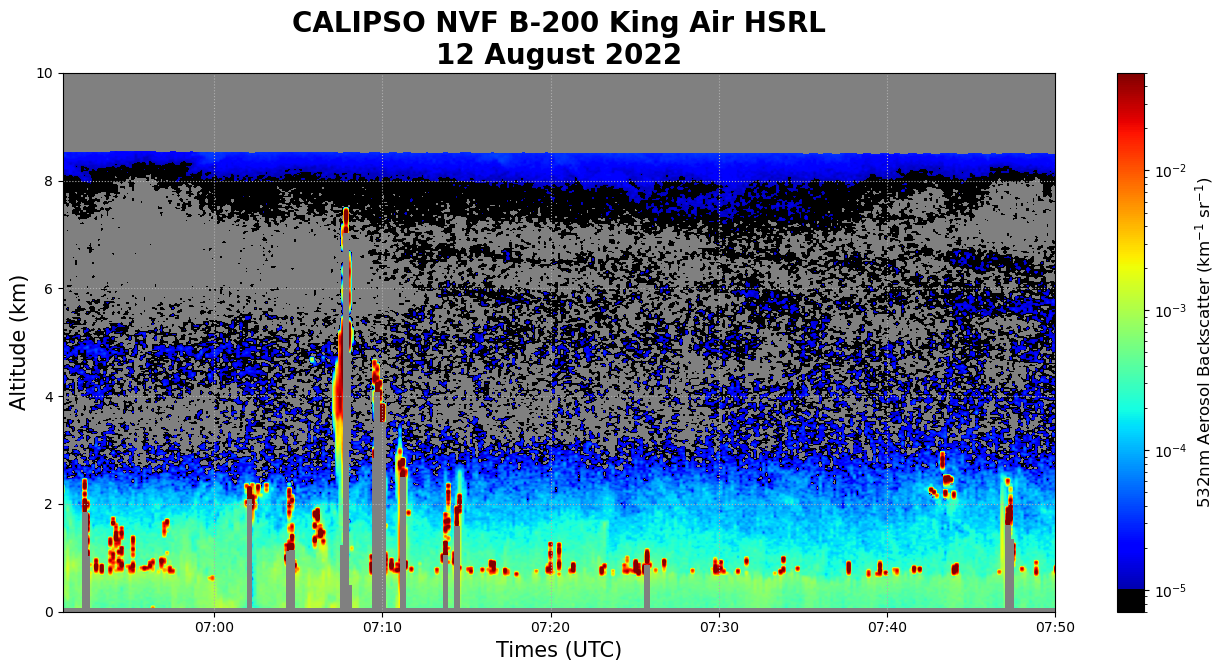

In [92]:
fig, ax = plt.subplots(figsize=(16, 7), facecolor="white")


bsr = ax.imshow(
    bsc_532nm,
    vmin=0.000007,
    vmax=0.05,
    norm="log",
    aspect="auto",
    cmap=newcmp,
    extent=(time_min, time_max, alt_max, alt_min),
)

ax.xaxis_date()
ax.set_facecolor("gray")
date_format = mdates.DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(date_format)
ax.set(xlabel="Times (UTC)", ylabel="Altitude (km)", xticks=time_ticks, yticks=alt_ticks)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)

cbar = plt.colorbar(bsr, ax=ax, norm="log")
cbar.set_label("532nm Aerosol Backscatter (km$^{-1}$ sr$^{-1}$)", size=12)

plt.title("CALIPSO NVF B-200 King Air HSRL\n12 August 2022", fontweight="bold", fontsize="20")
plt.xlim([datetime(2022, 8, 12, 6, 51), datetime(2022, 8, 12, 7, 50)])
plt.ylim([0, 10])
plt.grid(linestyle=":")

plt.show()

In [ ]:
plt.savefig("CALIPSO_NVF_532nmExtinctionTime_2022-8-12.png")

# 5. Create Another Plot with Latitude Labels
  - Create custom ticks labels to include known lat/lon points
  - Map data to axes and set as variable

In [ ]:
time_ticks_labels = [
    ("26.28 \u00b0N \n63.09  \u00b0W"),
    ("26.96 \u00b0N \n62.93  \u00b0W"),
    ("27.61 \u00b0N \n62.76  \u00b0W"),
    ("28.26 \u00b0N \n62.59  \u00b0W"),
    ("28.90 \u00b0N \n62.43  \u00b0W"),
    ("29.53 \u00b0N \n62.26  \u00b0W"),
]

fig2, ax2 = plt.subplots(figsize=(16, 7), facecolor="white")

bsr2 = ax2.imshow(
    bsc_532nm,
    vmin=0.000007,
    vmax=0.05,
    norm="log",
    aspect="auto",
    cmap=newcmp,
    extent=(time_min, time_max, alt_max, alt_min),
)


ax2.set_facecolor("gray")
ax2.set_xticks(time_ticks)
ax2.set_yticks(alt_ticks)

ax2.set(xlabel="Latitudes, Longitudes", ylabel="Altitude (km)", xticklabels=time_ticks_labels)
ax2.xaxis.label.set_size(15)
ax2.yaxis.label.set_size(15)

cbar2 = fig2.colorbar(bsr2, ax=ax2, norm="log")
cbar2.set_label("532nm Aerosol Backscatter (km$^{-1}$ sr$^{-1}$)", size=12)

plt.title("CALIPSO NVF B-200 King Air HSRL\n12 August 2022", fontweight="bold", fontsize="20")
plt.xlim([datetime(2022, 8, 12, 6, 51), datetime(2022, 8, 12, 7, 50)])
plt.ylim([0, 10])
plt.grid(linestyle=":")

plt.show()

- Name and export plot

In [ ]:
plt.savefig("CALIPSO_NVF_532nmExtinctionLat_2022-8-12.png")